# Cox-Time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_pandas import DataFrameMapper
import torch
import torchtuples as tt

from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime
from pycox.evaluation import EvalSurv

In [2]:
SEED = 50

In [3]:
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Dataset

In [ ]:
from dataset_11t5g_markov import DatasetMarkovSurvSurf

ds_name = 'markov_32feat_11t5g_more_balanced_largeN_censor'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_Markov_censored'
SAVE_PATH = f'./pycox_models/{project}/cox_time_pycox_{SEED}'
g_resol = 1
t_resol = 1
split = 'train'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_train = ds._get_df_Xy_trans_obs()

split = 'test'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_test = ds._get_df_Xy_true_prob()

split = 'val'
ds = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_val = ds._get_df_Xy_trans_obs()

In [5]:
df_test

,subject,g_max_by_time,duration,event_observed,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,1,1,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
1,1,2,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
2,1,3,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
3,1,4,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
4,1,5,0,0.000000,0.932866,2.059838,-0.934938,-1.612990,0.527070,-1.551101,...,-0.219661,1.503398,-1.482385,-0.856164,-0.828693,0.114048,0.527728,1.0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,3999,1,11,0.999999,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN
149996,3999,2,11,0.904258,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN
149997,3999,3,11,0.394033,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN
149998,3999,4,11,0.289010,-1.882847,-0.591056,0.588792,-1.098525,0.211081,-0.399733,...,0.353908,1.593427,-0.369155,-0.173656,-0.658836,0.828539,-1.077051,0.0,1,NaN


In [6]:
df_train.head()

,subject,event_observed,duration,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,0,0,8,1.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
1,4,1,4,3.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
2,4,1,8,4.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
3,4,0,10,5.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
4,8,1,2,1.0,-0.831544,-0.672747,0.670116,-1.148873,-0.267907,-0.951563,...,-0.164301,0.394063,-0.231680,-0.247626,-0.386632,0.022902,-0.712544,1.0,1,1


## Feature transforms

In [7]:
x_train = df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].astype('float32')
x_train['g_max_by_time'] = x_train['g_max_by_time']/ds.g_max
x_train = x_train.values

x_val = df_val.loc[:,df_val.columns.str.startswith('feat')|df_val.columns.str.startswith('g_max_by_time')].astype('float32')
x_val['g_max_by_time'] = x_val['g_max_by_time']/ds.g_max
x_val = x_val.values

x_test = df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].drop_duplicates().astype('float32')
x_test['g_max_by_time'] = x_test['g_max_by_time']/ds.g_max
x_test = x_test.values



In [8]:
df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].columns == (
    df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].columns
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

We need no label transforms

In [9]:
get_target = lambda df: (df['duration'].astype('float32').values, df['event_observed'].astype('float32').values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = tt.tuplefy(x_val, y_val)

In [10]:
val.shapes()

((1020, 33), ((1020,), (1020,)))

With `TupleTree` (the results of `tt.tuplefy`) we can easily repeat the validation dataset multiple times. This will be useful for reduce the variance of the validation loss, as the validation loss of `CoxTime` is not deterministic.

In [11]:
val.repeat(2).cat().shapes()

((2040, 33), ((2040,), (2040,)))

## Neural net
 
We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
The net required by `CoxTime` is slightly different than most of the other methods as it also take `time` and an additional input argument. 
We have therefore crated the `MLPVanillaCoxTime` class that is a suitable version of `tt.practical.MLPVanilla`.
This class also removes the options for setting `out_features` and `output_bias` as they should be `1` and `False`, respectively.
 
To see the code for the networks call `??MLPVanillaCoxTime`.

In [12]:
in_features = x_train.shape[1]
num_nodes = [32, 32, 32, 32]
batch_norm = False
dropout = 0

net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm, dropout)

## Training the model

In [13]:
model = CoxTime(net, tt.optim.Adam(lr=1e-2, weight_decay=1e-2))

In [14]:
batch_size = 64

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [15]:
epochs = 2000
callbacks = [tt.callbacks.EarlyStopping(patience=500)]
verbose = True

In [16]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val.repeat(10).cat())

0:	[0s / 0s],		train_loss: 0.7063,	val_loss: 0.6929
1:	[0s / 0s],		train_loss: 0.6929,	val_loss: 0.6905
2:	[0s / 0s],		train_loss: 0.6888,	val_loss: 0.6875
3:	[0s / 0s],		train_loss: 0.6871,	val_loss: 0.6791
4:	[0s / 1s],		train_loss: 0.6793,	val_loss: 0.6612
5:	[0s / 1s],		train_loss: 0.6611,	val_loss: 0.6450
6:	[0s / 1s],		train_loss: 0.6473,	val_loss: 0.6398
7:	[0s / 1s],		train_loss: 0.6217,	val_loss: 0.6435
8:	[0s / 1s],		train_loss: 0.6236,	val_loss: 0.6115
9:	[0s / 1s],		train_loss: 0.5973,	val_loss: 0.6117
10:	[0s / 1s],		train_loss: 0.6053,	val_loss: 0.5919
11:	[0s / 1s],		train_loss: 0.5697,	val_loss: 0.5866
12:	[0s / 2s],		train_loss: 0.5687,	val_loss: 0.5931
13:	[0s / 2s],		train_loss: 0.5541,	val_loss: 0.5623
14:	[0s / 2s],		train_loss: 0.5326,	val_loss: 0.5811
15:	[0s / 2s],		train_loss: 0.5338,	val_loss: 0.5696
16:	[0s / 2s],		train_loss: 0.5165,	val_loss: 0.5534
17:	[0s / 2s],		train_loss: 0.5396,	val_loss: 0.5497
18:	[0s / 2s],		train_loss: 0.5111,	val_loss: 0.5585
19:

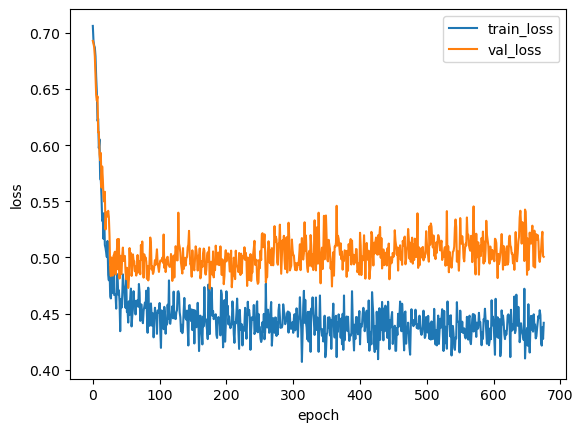

In [17]:
_ = log.plot()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig(f'{SAVE_PATH}_training_curves.pdf')
log.to_pandas().to_csv(f'{SAVE_PATH}_training_curves.csv')

We can get the partial log-likelihood

In [18]:
model.partial_log_likelihood(*val).mean()

-5.9647274

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxCC` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [19]:
_ = model.compute_baseline_hazards()

In [20]:
x_test.shape

(12500, 33)

In [21]:
x_test

array([[ 0.2       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       [ 0.4       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       [ 0.6       ,  0.93286633,  2.059838  , ...,  0.1140476 ,
         0.5277285 ,  1.        ],
       ...,
       [ 0.6       , -1.8828468 , -0.59105647, ...,  0.82853913,
        -1.0770508 ,  0.        ],
       [ 0.8       , -1.8828468 , -0.59105647, ...,  0.82853913,
        -1.0770508 ,  0.        ],
       [ 1.        , -1.8828468 , -0.59105647, ...,  0.82853913,
        -1.0770508 ,  0.        ]], dtype=float32)

In [22]:
surv = model.predict_surv_df(x_test)

In [23]:
surv

,0,1,2,3,4,5,6,7,8,9,...,12490,12491,12492,12493,12494,12495,12496,12497,12498,12499
duration,,,,,,,,,,,,,,,,,,,,,
1.0,0.773497,0.984447,0.999162,0.999955,0.999998,0.645154,0.917065,0.995333,0.999756,0.999987,...,0.673025,0.974719,0.998682,0.999932,0.999997,0.595920,0.973640,0.998622,0.999929,0.999996
2.0,0.662490,0.862426,0.992116,0.999577,0.999977,0.500020,0.724770,0.957741,0.997657,0.999873,...,0.530287,0.792062,0.987672,0.999362,0.999967,0.432233,0.766803,0.986191,0.999283,0.999963
3.0,0.584889,0.770548,0.916155,0.995328,0.999750,0.410314,0.603819,0.809148,0.975142,0.998627,...,0.438119,0.670771,0.872249,0.992945,0.999628,0.334721,0.605104,0.849496,0.991148,0.999516
4.0,0.540006,0.716881,0.858263,0.958016,0.997709,0.363098,0.539363,0.729049,0.885654,0.987915,...,0.384465,0.597068,0.786323,0.929810,0.996173,0.281204,0.515185,0.732227,0.917251,0.995296
5.0,0.504681,0.674343,0.812081,0.911282,0.973822,0.328565,0.491816,0.669496,0.818634,0.918677,...,0.338995,0.533727,0.711551,0.850610,0.950736,0.243875,0.451697,0.648492,0.819948,0.948268
6.0,0.465128,0.626371,0.759663,0.857928,0.922122,0.292487,0.441729,0.606282,0.746991,0.844179,...,0.287781,0.461314,0.624933,0.757784,0.857796,0.206623,0.387590,0.563016,0.719621,0.840601
7.0,0.430283,0.583786,0.712808,0.809937,0.875354,0.262789,0.400146,0.553383,0.686599,0.780956,...,0.244179,0.397747,0.547661,0.673777,0.772601,0.177384,0.336653,0.494330,0.638158,0.752333
8.0,0.407155,0.555339,0.681328,0.777525,0.843619,0.244219,0.373962,0.519859,0.648100,0.740432,...,0.218207,0.358515,0.497584,0.616680,0.713848,0.159792,0.305701,0.452211,0.587779,0.697319
9.0,0.381908,0.524108,0.646587,0.741345,0.807278,0.225008,0.346715,0.484783,0.607613,0.697615,...,0.192428,0.319220,0.447003,0.558560,0.651491,0.142184,0.274458,0.409360,0.536154,0.640568


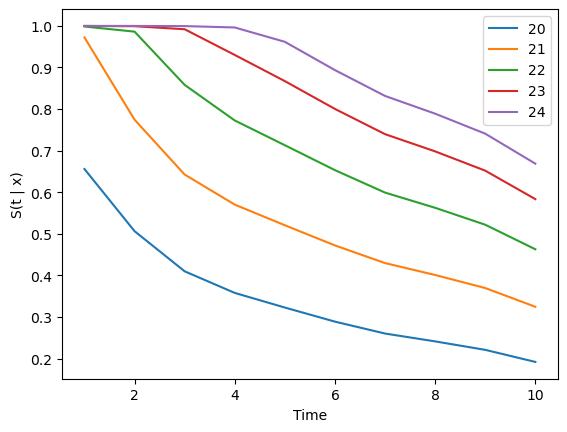

In [24]:
n = 5
surv.iloc[:, 5*(n-1):5*n].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

In [25]:
model.save_net(SAVE_PATH)